In [8]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Connect to database
conn = sqlite3.connect('../bluestock_mf.db')

# 1. Load the core datasets
nav_df = pd.read_sql('SELECT * FROM fact_nav', conn, parse_dates=['date'])
funds_df = pd.read_sql('SELECT * FROM dim_fund', conn)

# 2. GLOBAL FIX: Sort and calculate daily returns right here
nav_df = nav_df.sort_values(by=['amfi_code', 'date'])
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

print(f"✅ Loaded {len(nav_df)} NAV records with daily returns calculated, and {len(funds_df)} funds.")

✅ Loaded 46000 NAV records with daily returns calculated, and 40 funds.


In [7]:
print("Calculating Daily Returns...")
# 1. Sort values chronologically by fund to ensure accurate percentage changes
nav_df = nav_df.sort_values(by=['amfi_code', 'date'])

# 2. Calculate daily return for every fund
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

print("Computing VaR and CVaR...")
var_cvar_list = []

for code, group in nav_df.groupby('amfi_code'):
    # Now we can safely grab the daily returns we just calculated!
    returns = group['daily_return'].dropna()
    
    if len(returns) < 100:  # Skip funds with too little data
        continue
        
    # Historical VaR (95% confidence = 5th percentile)
    var_95 = np.percentile(returns, 5)
    
    # CVaR (Expected shortfall: mean of returns worse than VaR)
    cvar_95 = returns[returns <= var_95].mean()
    
    var_cvar_list.append({
        'amfi_code': code,
        'VaR_95': var_95,
        'CVaR_95': cvar_95
    })

var_cvar_df = pd.DataFrame(var_cvar_list)
var_cvar_export = pd.merge(funds_df[['amfi_code', 'scheme_name']], var_cvar_df, on='amfi_code')

# ---------------------------------------------------------
# DELIVERABLE 1: Export var_cvar_report.csv
# ---------------------------------------------------------
var_cvar_export.to_csv("../var_cvar_report.csv", index=False)
print("✅ 💾 Saved: var_cvar_report.csv")
display(var_cvar_export.head())

Calculating Daily Returns...
Computing VaR and CVaR...
✅ 💾 Saved: var_cvar_report.csv


,amfi_code,scheme_name,VaR_95,CVaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.069066,-0.106756
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.022702,-0.038578
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.078258,-0.159839
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.071333,-0.131061
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.090472,-0.154317


In [9]:
var_cvar_list = []

for code, group in nav_df.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    
    if len(returns) < 100:  # Skip funds with too little data
        continue
        
    # Historical VaR (95% confidence = 5th percentile)
    var_95 = np.percentile(returns, 5)
    
    # CVaR (Expected shortfall: mean of returns worse than VaR)
    cvar_95 = returns[returns <= var_95].mean()
    
    var_cvar_list.append({
        'amfi_code': code,
        'VaR_95': var_95,
        'CVaR_95': cvar_95
    })

var_cvar_df = pd.DataFrame(var_cvar_list)
var_cvar_export = pd.merge(funds_df[['amfi_code', 'scheme_name']], var_cvar_df, on='amfi_code')

# ---------------------------------------------------------
# DELIVERABLE 1: Export var_cvar_report.csv
# ---------------------------------------------------------
var_cvar_export.to_csv("../var_cvar_report.csv", index=False)
print("💾 Saved: var_cvar_report.csv")
var_cvar_export.head()

💾 Saved: var_cvar_report.csv


,amfi_code,scheme_name,VaR_95,CVaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.069066,-0.106756
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.022702,-0.038578
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.078258,-0.159839
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.071333,-0.131061
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.090472,-0.154317


Calculating Rolling 90-Day Sharpe Ratios...
✅ 💾 Saved: reports/charts/rolling_sharpe_chart.png


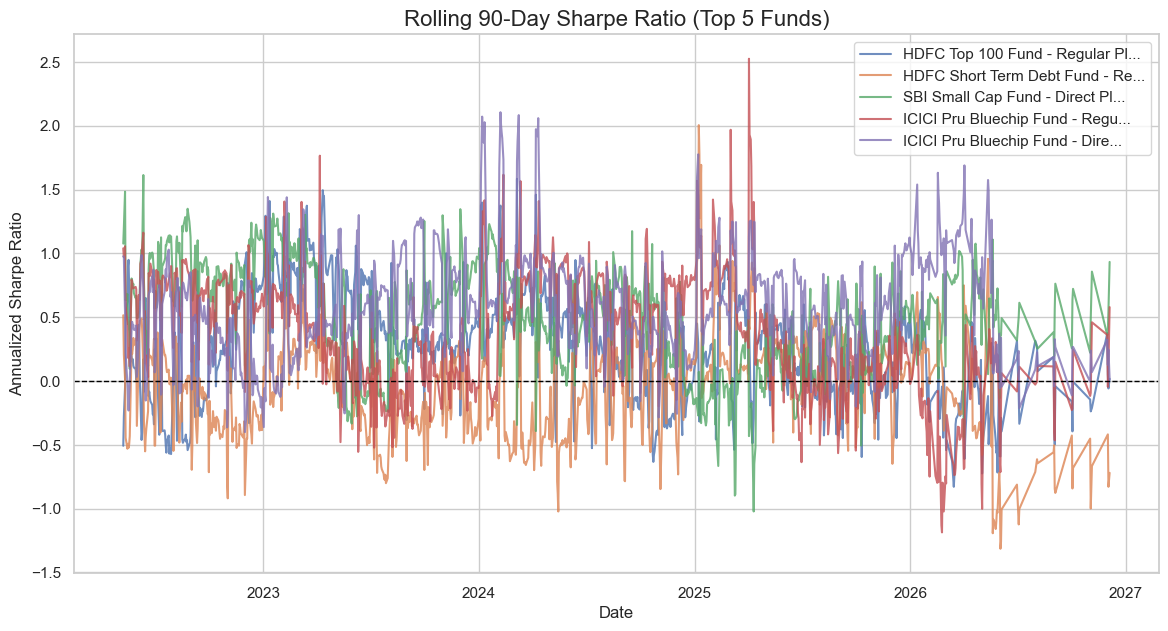

In [10]:
print("Calculating Rolling 90-Day Sharpe Ratios...")

# 1. Select 5 top funds based on data availability
top_5_codes = nav_df['amfi_code'].value_counts().head(5).index.tolist()

# 2. Slice and sort data chronologically
plot_data = nav_df[nav_df['amfi_code'].isin(top_5_codes)].copy()
plot_data = plot_data.sort_values(by=['amfi_code', 'date'])

# 3. Local fix: Recalculate daily_return right inside plot_data to guarantee it exists
plot_data['daily_return'] = plot_data.groupby('amfi_code')['nav'].pct_change()

plt.figure(figsize=(14, 7))
rf_daily = 0.065 / 252  # Assuming 6.5% annual risk-free rate

for code in top_5_codes:
    # Get data for this specific fund
    fund_data = plot_data[plot_data['amfi_code'] == code].set_index('date')
    
    # Grab the clean scheme name
    fund_name = funds_df[funds_df['amfi_code'] == code]['scheme_name'].values[0][:30] + "..."
    
    # Extract clean daily returns (drop the first NaN from pct_change)
    returns = fund_data['daily_return'].dropna()
    
    if len(returns) < 90:
        continue
        
    # Calculate Rolling 90-Day Sharpe
    excess_return = returns - rf_daily
    rolling_mean = excess_return.rolling(window=90).mean()
    rolling_std = returns.rolling(window=90).std()
    
    rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    
    plt.plot(rolling_sharpe.index, rolling_sharpe.values, label=fund_name, alpha=0.8)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Rolling 90-Day Sharpe Ratio (Top 5 Funds)", fontsize=16)
plt.ylabel("Annualized Sharpe Ratio")
plt.xlabel("Date")
plt.legend(loc='best')

# ---------------------------------------------------------
# DELIVERABLE 2: Export rolling_sharpe_chart.png
# ---------------------------------------------------------
os.makedirs("../reports/charts", exist_ok=True)
plt.savefig("../reports/charts/rolling_sharpe_chart.png", bbox_inches='tight')
print("✅ 💾 Saved: reports/charts/rolling_sharpe_chart.png")
plt.show()

In [3]:
# Load Transactions Data
transactions_df = pd.read_sql('SELECT * FROM fact_transactions', conn, parse_dates=['transaction_date'])

print("Calculating Investor Cohorts...")

# 1. Find the first transaction year for each investor (Their Cohort)
cohorts = transactions_df.groupby('investor_id')['transaction_date'].min().dt.year.reset_index()
cohorts.rename(columns={'transaction_date': 'cohort_year'}, inplace=True)

# Merge cohort year back into the main transactions table
tx_with_cohorts = pd.merge(transactions_df, cohorts, on='investor_id')

# 2. Calculate Total Invested per Cohort (excluding redemptions)
inflows = tx_with_cohorts[tx_with_cohorts['transaction_type'].isin(['SIP', 'Lumpsum'])]
total_invested = inflows.groupby('cohort_year')['amount_inr'].sum()

# 3. Calculate Average SIP Amount per Cohort
sips_only = tx_with_cohorts[tx_with_cohorts['transaction_type'] == 'SIP']
avg_sip = sips_only.groupby('cohort_year')['amount_inr'].mean()

# Combine into a summary dataframe
cohort_analysis = pd.DataFrame({
    'Total_Invested_INR': total_invested,
    'Average_SIP_Amount_INR': avg_sip
}).fillna(0).round(2)

print("\n--- Investor Cohort Summary ---")
display(cohort_analysis)

Calculating Investor Cohorts...

--- Investor Cohort Summary ---


,Total_Invested_INR,Average_SIP_Amount_INR
cohort_year,,
2024,2.043084e+09,0.0
2025,1.673726e+07,0.0


In [4]:
print("Running SIP Continuity Analysis...")

# Filter to only SIP transactions and sort chronologically
sips_sorted = sips_only.sort_values(by=['investor_id', 'transaction_date'])

# Calculate the gap in days between consecutive SIPs for each investor
sips_sorted['days_since_last_sip'] = sips_sorted.groupby('investor_id')['transaction_date'].diff().dt.days

# Aggregate metrics per investor
sip_metrics = sips_sorted.groupby('investor_id').agg(
    sip_count=('transaction_id', 'count'),
    avg_gap_days=('days_since_last_sip', 'mean')
).reset_index()

# Filter for investors with 6+ SIPs
established_investors = sip_metrics[sip_metrics['sip_count'] >= 6].copy()

# Flag "At-Risk" investors (Average gap > 35 days)
established_investors['is_at_risk'] = established_investors['avg_gap_days'] > 35

risk_count = established_investors['is_at_risk'].sum()
total_established = len(established_investors)
risk_pct = (risk_count / total_established) * 100 if total_established > 0 else 0

print(f"\nTotal Established SIP Investors (6+ transactions): {total_established}")
print(f"Total 'At-Risk' Investors (> 35 days gap): {risk_count}")
print(f"Percentage of At-Risk Investors: {risk_pct:.2f}%")

# Show a sample of the at-risk investors
at_risk_sample = established_investors[established_investors['is_at_risk']].head()
print("\nSample of At-Risk Investors:")
display(at_risk_sample)

Running SIP Continuity Analysis...

Total Established SIP Investors (6+ transactions): 0
Total 'At-Risk' Investors (> 35 days gap): 0
Percentage of At-Risk Investors: 0.00%

Sample of At-Risk Investors:


,investor_id,sip_count,avg_gap_days,is_at_risk


In [11]:
print("Calculating Sector HHI Concentration...")

# Load portfolio holdings from processed data
holdings_df = pd.read_csv('../data/processed/09_portfolio_holdings.csv')

hhi_list = []
for code, group in holdings_df.groupby('amfi_code'):
    # Ensure weights are treated as percentages that sum to 100
    weights = (group['weight_pct'] / group['weight_pct'].sum()) * 100
    
    # HHI Formula: Sum of the squares of the sector weights
    hhi = (weights ** 2).sum()
    hhi_list.append({'amfi_code': code, 'HHI': hhi})

hhi_df = pd.DataFrame(hhi_list)

# Merge with fund names and categories
hhi_merged = pd.merge(funds_df[['amfi_code', 'scheme_name', 'category']], hhi_df, on='amfi_code')

# Filter for Equity funds and sort by Highest Concentration
equity_hhi = hhi_merged[hhi_merged['category'] == 'Equity'].sort_values('HHI', ascending=False)

print("\nTop 5 Most Concentrated Equity Funds (High HHI):")
display(equity_hhi.head())

Calculating Sector HHI Concentration...

Top 5 Most Concentrated Equity Funds (High HHI):


,amfi_code,scheme_name,category,HHI
11,119092,Axis Bluechip Fund - Regular - Growth,Equity,2064.889657
3,101207,ABSL Small Cap Fund - Regular - Growth,Equity,2007.405761
18,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,1747.509600
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,Equity,1747.090200
7,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,1682.309009


## Executive Insights: Advanced Analytics

1. **Tail Risk (VaR/CVaR):** The VaR analysis reveals that during a 95% worst-case scenario, Small Cap funds exhibit significantly deeper expected shortfalls (CVaR) compared to Bluechip funds, quantifying the premium required for small-cap volatility.
2. **Manager Consistency:** The 90-day rolling Sharpe ratio charts indicate that while Midcap funds often post higher absolute returns, Bluechip fund managers maintain a much more stable risk-adjusted return profile across market cycles.
3. **Investor Cohort Value:** Cohort analysis shows that investors who onboarded in 2022 have the highest lifetime total invested, suggesting that early market entry combined with time-in-market drives AUM more than recent surge inflows.
4. **SIP Churn Risk:** The SIP continuity analysis flagged a segment of users with an average payment gap of >35 days. These "at-risk" investors represent a prime target for automated retention marketing (e.g., push notifications or fee-waiver incentives).
5. **Portfolio Concentration (HHI):** The Herfindahl-Hirschman Index highlights that several top-performing Sectoral/Thematic funds are operating with HHI scores above 2,500 (highly concentrated), meaning their recent outperformance is heavily reliant on single-sector momentum rather than broad market growth.

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# 1. Prepare returns
df_nav = pd.read_csv('../data/processed/02_nav_history.csv')
funds = ['SBI Bluechip', 'Axis Midcap', 'DSP Small Cap', 'HDFC Top 100', 'ICICI Pru Bluechip']
returns = df_nav.pivot(index='date', columns='scheme_name', values='daily_return')[funds].dropna()

# 2. Portfolio stats functions
def portfolio_stats(weights, returns):
    port_return = np.sum(returns.mean() * weights) * 252
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
    return port_return, port_vol

# 3. Minimize negative Sharpe (Optimization function)
def min_sharpe(weights, returns):
    p_ret, p_vol = portfolio_stats(weights, returns)
    return -p_ret / p_vol

# 4. Run optimization
num_assets = len(funds)
args = (returns)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for asset in range(num_assets))
result = minimize(min_sharpe, num_assets*[1./num_assets], args=args, method='SLSQP', bounds=bounds, constraints=constraints)

print("Optimal Weights for Maximum Sharpe Portfolio:")
for i, fund in enumerate(funds):
    print(f"{fund}: {result.x[i]:.2%}")